In [1]:
!pip install skorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 13.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pickle

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from skorch import NeuralNetRegressor
from skorch.callbacks import ProgressBar, LRScheduler, Checkpoint, EarlyStopping, EpochScoring
from skorch.helper import SliceDict

import torch
import torch.nn as nn

from transformers import BertTokenizer, BertModel

In [4]:
# ===== CONFIG =====
SEED = 42
MAX_LEN = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WEIGHTS_PATH = "/content/drive/MyDrive/GSIdetect/bert_resize/weights.pth" #"/content/drive/MyDrive/Colab Notebooks/weights.pth"
DATA_PATH = "/content/drive/MyDrive/GSIdetect/dati/train.pkl" #"/content/drive/MyDrive/Colab Notebooks/train.pkl"  # _dataset_completo.pkl"
TOKENIZER_PATH = "/content/drive/MyDrive/GSIdetect/bert_resize" #"/content/drive/MyDrive/Colab Notebooks/tokenizer"

torch.manual_seed(SEED)
np.random.seed(SEED)

# Obiettivo dell’esperimento

L’obiettivo di questo notebook è affrontare un problema di **regressione su testo in lingua italiana** nell’ambito della challenge [EVALITA GSI:detect (Detecting Gender Stereotypes in Italian)](https://gsi-d-evalita.fbk.eu/home) utilizzando un modello BERT pre-addestrato, confrontando due strategie:

- **Feature extraction** (BERT congelato)
- **Fine-tuning completo** del modello

Il confronto è effettuato in termini di **Mean Squared Error (MSE)**, utilizzando
cross-validation stratificata per garantire stabilità statistica rispetto alla distribuzione delle categorie.

In [5]:
tokenizer = BertTokenizer.from_pretrained(TOKENIZER_PATH)
print(f"len(tokenizer)={len(tokenizer)}")

len(tokenizer)=31197


In [6]:
with open(DATA_PATH, "rb") as f:
    data = pickle.load(f)

texts = data["text"]
values = data["gs_value"]
categories = data["gs_category"]

In [7]:
def prepare_data(text_series, tokenizer, max_len):
    enc = tokenizer(
        text_series.tolist(),
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="np"
    )
    X = SliceDict(
        input_ids=enc["input_ids"],
        attention_mask=enc["attention_mask"]
    )
    return X

In [8]:
X = prepare_data(texts, tokenizer, MAX_LEN)
y = values.values.astype(np.float32).reshape(-1, 1)
print(f"len(X)={len(X)}, len(y)={len(y)}")

len(X)=382, len(y)=382


## Baseline di riferimento

Prima di addestrare modelli complessi, viene calcolata una baseline
utilizzando un DummyRegressor che predice sempre la media.

Un modello che non supera tale valore è da considerarsi non informativo, ma un modello che lo supera è ancora da intendersi come potenziale candidato e non necessariamente ottimale per gli obiettivi della challenge.

In [9]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X, y)
preds = dummy.predict(X)
baseline_mse = mean_squared_error(y, preds)

print(f"MSE se predicessi sempre la media: {baseline_mse:.4f}")

MSE se predicessi sempre la media: 0.1412


## Strategia di validazione

La valutazione è effettuata tramite cross-validation stratificata
rispetto alle categorie del dataset (`gs_category`), al fine di preservare la distribuzione
dei dati nei vari split e ridurre la varianza della stima dell’errore.

In [10]:
y_cats = categories.values
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_splits = list(skf.split(X, y_cats))

# Scelta del modello linguistico

Si utilizza [`dbmdz/bert-base-italian-xxl-cased`](https://huggingface.co/dbmdz/bert-base-italian-xxl-cased), un modello BERT addestrato specificamente su
corpora italiani.

Il modello viene adattato a regressione tramite:

- una **testa fully-connected dedicata**
- **mean pooling sugli embeddings contestuali**

## Testa di regressione

Gli embeddings pooled vengono passati a una rete fully-connected
con riduzione progressiva della dimensionalità.

La testa fully-connected è progettata per:

- ridurre progressivamente la dimensionalità
- migliorare la stabilità con BatchNorm
- limitare l’overfitting tramite Dropout, soprattutto in un caso come questo con pochi dati di addestramento

L’output è vincolato in \[0, 1\] tramite funzione Sigmoid,
in accordo con il dominio del target della challenge.

## Pooling degli embeddings

Invece di utilizzare il solo token `[CLS]`, viene adottata una strategia di
**mean pooling pesato sull’attention mask**.

Questa scelta consente di:

- incorporare l’informazione di tutti i token rilevanti
- ottenere rappresentazioni più stabili per task di regressione
- ridurre la dipendenza da un singolo token speciale

In [11]:
class BertRegressor(nn.Module):
    def __init__(self, freeze_bert, tokenizer_len):
        super().__init__()
        self.bert = BertModel.from_pretrained("dbmdz/bert-base-italian-xxl-cased")
        if tokenizer_len:
            self.bert.resize_token_embeddings(tokenizer_len)
        try:
            state_dict = torch.load(WEIGHTS_PATH, map_location="cpu")
            state_dict_fixed = {k.replace('bert.', '', 1): v for k, v in state_dict.items()}
            self.bert.load_state_dict(state_dict_fixed, strict=False)
            print("Pesi caricati.")
        except:
            print("Errore caricamento pesi.")
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False
        input_dim = self.bert.config.hidden_size  # 768
        self.regressor = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = out.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        mean_pooling = sum_embeddings / sum_mask
        return self.regressor(mean_pooling)

In [12]:
risultati = {}

# Perché Skorch

Skorch è utilizzato come interfaccia tra PyTorch e scikit-learn per tre motivi chiave:

1. **Integrazione nativa e diretta con `GridSearchCV`, come suggerito nella [documentazione](https://skorch.readthedocs.io/en/stable/user/quickstart.html)**
2. **Gestione automatica di training / validation / callbacks**
3. **Riproducibilità e tracciamento delle metriche per epoca**

Questo approccio permette di trattare modelli deep learning come stimatori sklearn,
rendendo il confronto sperimentale più rigoroso e standardizzato (`fit`, `best_params_`, `best_score_`, `best_estimator_`, `best_estimator_.history`, ...).

Il notebook del task di classificazione segue invece il classico approccio con train_loop e test_loop in puro torch.

Osservazione: poiché la GridSearch è progettata per massimizzare i punteggi, utilizziamo `neg_mean_squared_error` per trasformare l'errore in un valore negativo (dove il numero 'più alto' corrisponde all'errore minore) e applichiamo il segno meno finale per visualizzare il reale MSE positivo.

In [13]:
def addestra(freeze_bert, X, y):
    print(f"freeze_bert={freeze_bert}")

    cp = Checkpoint(monitor='valid_loss_best', dirname=f'/content/drive/MyDrive/Colab Notebooks/exp_freeze_{freeze_bert}', load_best=True)
    es = EarlyStopping(monitor='valid_loss', patience=5)
    scheduler = LRScheduler(policy='ReduceLROnPlateau', monitor='valid_loss',
                            patience=3, factor=0.5)

    net = NeuralNetRegressor(
        module=BertRegressor,
        module__tokenizer_len=len(tokenizer),
        module__freeze_bert=freeze_bert,
        criterion=nn.MSELoss,
        optimizer=torch.optim.AdamW,
        optimizer__weight_decay=0.01,
        device=DEVICE,
        max_epochs=30,
        iterator_train__shuffle=True,
        iterator_train__drop_last=True,
        callbacks=[cp, es, scheduler],
        verbose=1,
    )

    params = {
        'optimizer__lr': [1e-3, 5e-4] if freeze_bert else [1e-5, 2e-5],
        'batch_size':      [32, 64]   if freeze_bert else [16]
    }

    gs = GridSearchCV(
        net,
        params,
        refit=True,
        cv=cv_splits,
        scoring='neg_mean_squared_error',
        verbose=3
    )

    gs.fit(X, y)

    print("Migliori iperparametri:", gs.best_params_)
    print("Miglior MSE:", -gs.best_score_)

    return gs.best_estimator_, gs.best_estimator_.history

# Confronto tra strategie di addestramento

Vengono confrontate due modalità:

- **Freeze=True**: BERT utilizzato come estrattore di feature
- **Freeze=False**: fine-tuning completo del modello

## Mode 1 - Freeze (Feature Extraction)

- I pesi di BERT sono congelati
- Learning rate più alto per addestrare solo la testa di regressione
- Batch size maggiore, con minore utilizzo di memoria

## Mode 2 - Fine-Tuning

- Tutti i pesi del modello vengono aggiornati
- Learning rate molto basso per evitare catastrophic forgetting
- Batch size ridotto per limiti di memoria GPU

In [14]:
for freeze_bert in [True, False]:
    best_est, history = addestra(freeze_bert, X, y)
    risultati[freeze_bert] = {
        "model": best_est,
        "history": history,
        "train_loss": history[:, 'train_loss'],
        "valid_loss": history[:, 'valid_loss']
    }
    best_est.save_params(f_params=f"/content/drive/MyDrive/Colab Notebooks/regression_freeze_{freeze_bert}.pkl")

freeze_bert=True
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: dbmdz/bert-base-italian-xxl-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pesi caricati.
  epoch    train_loss    valid_loss    cp      lr     dur
-------  ------------  ------------  ----  ------  ------
      1        0.1774        0.1615     +  0.0000  4.5795
      2        0.1377        0.1578     +  0.0000  4.6557
      3        0.0999        0.1562     +  0.0000  4.7537
      4        0.0920        0.1569        0.0000  4.7647
      5        0.0742        0.1576        0.0000  4.8030
      6        0.0676        0.1643        0.0000  4.9521
      7        0.0523        0.1683        0.0000  4.9440
Stopping since valid_loss has not improved in the last 5 epochs.
[CV 3/3] END batch_size=16, optimizer__lr=2e-05;, score=-0.136 total time= 2.4min


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-italian-xxl-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pesi caricati.
  epoch    train_loss    valid_loss    cp      lr     dur
-------  ------------  ------------  ----  ------  ------
      1        0.1557        0.1703     +  0.0000  7.1036
      2        0.1363        0.1646     +  0.0000  7.2740
      3        0.1074        0.1619     +  0.0000  7.4694
      4        0.0890        0.1584     +  0.0000  7.3989
      5        0.0865        0.1582     +  0.0000  7.5211
      6        0.0748        0.1579     +  0.0000  7.6553
      7        0.0624        0.1565     +  0.0000  7.2207
      8        0.0566        0.1532     +  0.0000  7.4264
      9        0.0492        0.1530     +  0.0000  7.4430
     10        0.0471        0.1526     +  0.0000  7.4729
     11        0.0431        0.1575        0.0000  7.3423
     12        0.0390        0.1592        0.0000  7.4690
     13        0.0324        0.1578        0.0000  7.6808
     14        0.0316        0.1571        0.0000  7.5990
Stopping since valid_loss has not improved in the last 5 

# Valutazione dei risultati

A questo punto vengono confrontati i valori del dizionario `risultati` e vengono stampati i grafici della loss e del MSE.

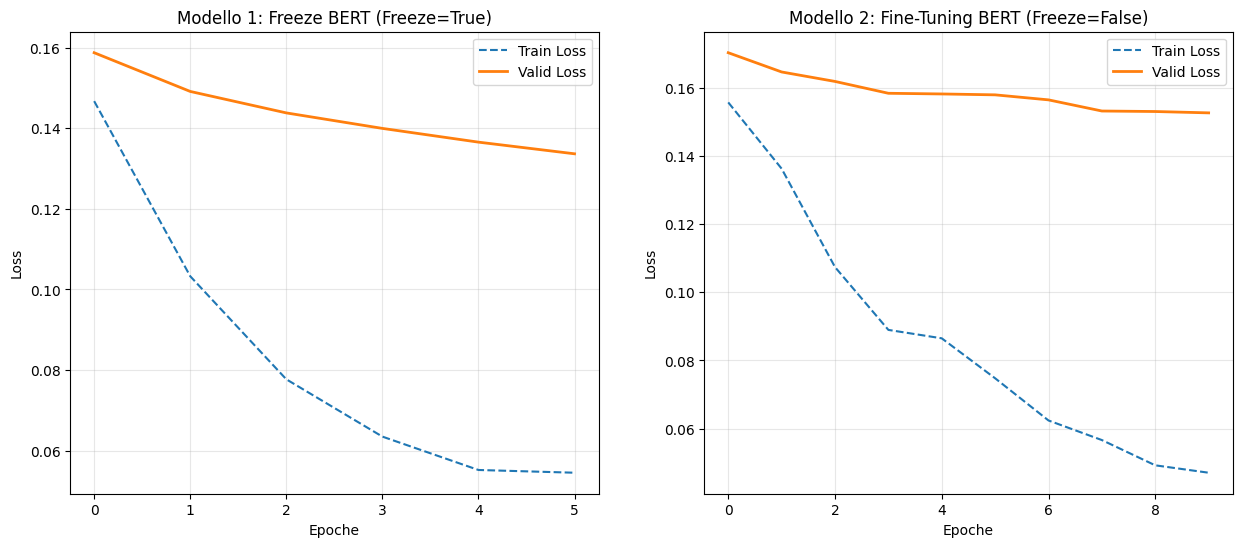

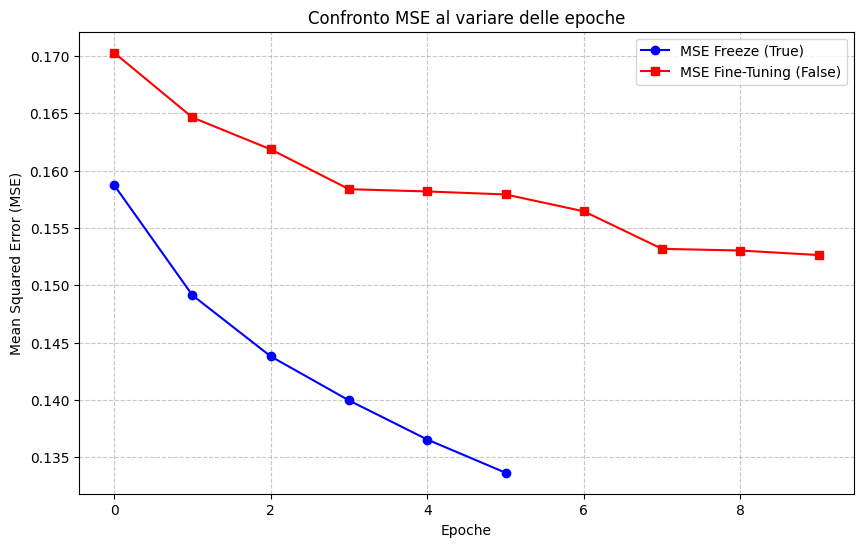

In [15]:
hist_freeze = risultati[True]['history']
hist_finetune = risultati[False]['history']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(hist_freeze[:, 'train_loss'], label='Train Loss', linestyle='--')
ax1.plot(hist_freeze[:, 'valid_loss'], label='Valid Loss', linewidth=2)
ax1.set_title("Modello 1: Freeze BERT (Freeze=True)")
ax1.set_xlabel("Epoche")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(hist_finetune[:, 'train_loss'], label='Train Loss', linestyle='--')
ax2.plot(hist_finetune[:, 'valid_loss'], label='Valid Loss', linewidth=2)
ax2.set_title("Modello 2: Fine-Tuning BERT (Freeze=False)")
ax2.set_xlabel("Epoche")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(hist_freeze[:, 'valid_loss'], label='MSE Freeze (True)', marker='o', color='blue')
plt.plot(hist_finetune[:, 'valid_loss'], label='MSE Fine-Tuning (False)', marker='s', color='red')
plt.title("Confronto MSE al variare delle epoche")
plt.xlabel("Epoche")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Selezione del modello

Il modello finale viene scelto in base al miglior valore di MSE
ottenuto in validazione, privilegiando la capacità di generalizzazione
rispetto alla semplice ottimizzazione della loss di training.

## Inferenza su test set

Una volta selezionato il modello migliore, viene utilizzato per
generare predizioni sul test set.

I risultati CSV e i pesi del modello vengono salvati per garantire
riproducibilità e utilizzo futuro.

In [16]:
mse_freeze = min(risultati[True]['valid_loss'])
mse_finetune = min(risultati[False]['valid_loss'])
print(f"Miglior MSE (Freeze=True):  {mse_freeze:.5f}")
print(f"Miglior MSE (Freeze=False): {mse_finetune:.5f}")

if mse_finetune < mse_freeze:
    print("\n>>> VINCITORE: Fine-Tuning (Freeze=False)")
    best_overall_model = risultati[False]['model']
    best_mode_str = "finetuning"
else:
    print("\n>>> VINCITORE: Freeze (Freeze=True)")
    best_overall_model = risultati[True]['model']
    best_mode_str = "freeze"

TEST_PATH = "/content/drive/MyDrive/GSIdetect/dati/test.pkl" #"/content/drive/MyDrive/Colab Notebooks/test.pkl"  # _pulito.pkl"

with open(TEST_PATH, "rb") as f:
    test_data = pickle.load(f)

X_test_text = test_data["text"]
if hasattr(X_test_text, 'reset_index'):
    X_test_text = X_test_text.reset_index(drop=True)

X_test = prepare_data(X_test_text, tokenizer, MAX_LEN)
print(f"len(X_test)={len(X_test)}")

test_preds = best_overall_model.predict(X_test)

df_results = pd.DataFrame({
    "text": X_test_text,
    "predicted_value": np.clip(test_preds.flatten(), 0.0, 1.0)
})

SAVE_CSV_PATH = f"/content/drive/MyDrive/GSIdetect/risultati_test_BEST_{best_mode_str}.csv" #f"/content/drive/MyDrive/Colab Notebooks/risultati_test_BEST_{best_mode_str}.csv"
SAVE_MODEL_PATH = f"/content/drive/MyDrive/GSIdetect/best_model_{best_mode_str}.pkl" #f"/content/drive/MyDrive/Colab Notebooks/best_model_{best_mode_str}.pkl"

df_results.to_csv(SAVE_CSV_PATH, index=False)
best_overall_model.save_params(f_params=SAVE_MODEL_PATH)

print(f"CSV salvato in: {SAVE_CSV_PATH}")
print(f"Modello salvato in: {SAVE_MODEL_PATH}")

print(df_results.head())

Miglior MSE (Freeze=True):  0.13366
Miglior MSE (Freeze=False): 0.15264

>>> VINCITORE: Freeze (Freeze=True)
len(X_test)=810
CSV salvato in: /content/drive/MyDrive/GSIdetect/risultati_test_BEST_freeze.csv
Modello salvato in: /content/drive/MyDrive/GSIdetect/best_model_freeze.pkl
                                                text  predicted_value
0  [Contesto: parlante donna] Vorrei dedicare un ...         0.662107
1  Le gente appena ti vede ti chiede come mai non...         0.577766
2  Tenete duro ancora qualche giorno e i vostri f...         0.708190
3  Ma perché l'unico uomo in questa storia è piu ...         0.536931
4  Sentivo qualcosa di speciale e sai, una donna ...         0.569732
